# 🗂️ Bloque 1 — Sesión 2: Identificación de entidades y relaciones

**Módulo:** Depuración, limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD1 — Análisis exploratorio de datos  
**Duración estimada:** ~4 horas.

---

### Contenidos de esta sesión
- **1.3** Identificación de entidades y relaciones entre ellas

### Criterios de evaluación asociados
> **(CE a)** Se han descrito técnicas y posibilidades de almacenaje de los datos para componer conjuntos, identificando su naturaleza.  
> **(CE d)** Se han identificado entidades, volumetrías, relaciones y atributos, para documentar cada conjunto de datos, describiendo sus características.

In [22]:
# Librerías necesarias para esta sesión
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1.3 Identificación de entidades y relaciones entre ellas

Antes de limpiar o modelar datos, necesitamos entender **qué representan**. Los conceptos de entidad, atributo y relación provienen del modelado de bases de datos, pero son igualmente útiles para comprender cualquier conjunto de datos tabulares.

### Conceptos fundamentales

| Concepto | Definición | Ejemplo |
|----------|------------|---------|
| **Entidad** | Objeto o concepto del mundo real sobre el que registramos información | `Cliente`, `Producto`, `Pedido`, `Sensor` |
| **Atributo** | Propiedad o característica de una entidad | `nombre`, `precio`, `fecha_pedido`, `temperatura` |
| **Clave primaria (PK)** | Atributo (o combinación) que identifica unívocamente cada instancia | `id_cliente`, `cod_producto` |
| **Clave foránea (FK)** | Atributo que referencia la clave primaria de otra entidad | `id_cliente` en la tabla `Pedido` |
| **Relación** | Vínculo semántico entre dos entidades | Un `Cliente` realiza varios `Pedidos` |

### Tipos de relaciones (cardinalidad)

```
1 : 1  →  Un pasaporte pertenece a un único ciudadano (y viceversa)
1 : N  →  Un cliente puede tener muchos pedidos; cada pedido es de un solo cliente
N : M  →  Un pedido puede contener varios productos; un producto puede estar en varios pedidos
```

> 💡 En Machine Learning, identificar las entidades y sus relaciones es clave para:
> - Saber qué tabla es la **unidad de análisis** (nivel de granularidad del dataset)
> - Detectar **fugas de datos** (data leakage) por joins incorrectos
> - Calcular **características agregadas** (features) a partir de tablas relacionadas

### 📌 Ejemplo 1 — Identificar entidades y atributos en un DataFrame

In [23]:
# Cargamos el dataset Titanic y analizamos qué entidad representa
titanic = sns.load_dataset('titanic')

print('Dataset: Titanic')
print(f'Dimensiones: {titanic.shape[0]} filas × {titanic.shape[1]} columnas')
print(f'\nColumnas: {titanic.columns.tolist()}')
print()
titanic.head(3)

Dataset: Titanic
Dimensiones: 891 filas × 15 columnas

Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [24]:
# Análisis de la entidad representada
print('═' * 55)
print('ANÁLISIS DE ENTIDAD — Titanic')
print('═' * 55)
print()
print('ENTIDAD PRINCIPAL:  Pasajero')
print('GRANULARIDAD:       Una fila = un pasajero')
print()
print('ATRIBUTOS:')
atributos = {
    'survived':   ('Variable objetivo',      'Booleana'),
    'pclass':     ('Clase del billete',       'Categórica ordinal (1>2>3)'),
    'sex':        ('Sexo del pasajero',       'Categórica nominal'),
    'age':        ('Edad en años',            'Numérica continua'),
    'sibsp':      ('Hermanos/cónyuge a bordo','Numérica discreta'),
    'parch':      ('Padres/hijos a bordo',    'Numérica discreta'),
    'fare':       ('Precio del billete (£)',  'Numérica continua'),
    'embarked':   ('Puerto de embarque',      'Categórica nominal'),
    'name':       ('Nombre completo',         'Texto libre (identificador)'),
    'ticket':     ('Número de billete',       'Texto libre (identificador)'),
    'cabin':      ('Cabina asignada',         'Texto libre (semi-identificador)'),
}
for col, (descripcion, tipo) in atributos.items():
    print(f'  {col:12s} → {descripcion:35s} [{tipo}]')

print()
print('CLAVE PRIMARIA:     No explícita. "name" + "ticket" podrían actuar como PK.')
print('CLAVES FORÁNEAS:    Ninguna visible. Es un dataset desnormalizado (solo 1 tabla).')

═══════════════════════════════════════════════════════
ANÁLISIS DE ENTIDAD — Titanic
═══════════════════════════════════════════════════════

ENTIDAD PRINCIPAL:  Pasajero
GRANULARIDAD:       Una fila = un pasajero

ATRIBUTOS:
  survived     → Variable objetivo                   [Booleana]
  pclass       → Clase del billete                   [Categórica ordinal (1>2>3)]
  sex          → Sexo del pasajero                   [Categórica nominal]
  age          → Edad en años                        [Numérica continua]
  sibsp        → Hermanos/cónyuge a bordo            [Numérica discreta]
  parch        → Padres/hijos a bordo                [Numérica discreta]
  fare         → Precio del billete (£)              [Numérica continua]
  embarked     → Puerto de embarque                  [Categórica nominal]
  name         → Nombre completo                     [Texto libre (identificador)]
  ticket       → Número de billete                   [Texto libre (identificador)]
  cabin        → Cabi

### 📌 Ejemplo 2 — Esquema multientidad con claves primarias y foráneas

In [25]:
# Creamos un esquema realista de tres entidades relacionadas: tienda online

clientes = pd.DataFrame({
    'id_cliente':  [1, 2, 3, 4, 5],
    'nombre':      ['Ana García', 'Luis Martínez', 'María López', 'Carlos Ruiz', 'Elena Pérez'],
    'ciudad':      ['Sevilla', 'Madrid', 'Málaga', 'Barcelona', 'Valencia'],
    'premium':     [True, False, True, False, True],
    'fecha_alta':  pd.to_datetime(['2023-01-15', '2023-03-20', '2022-11-01',
                                   '2024-01-08', '2023-07-22'])
})

productos = pd.DataFrame({
    'id_producto': [101, 102, 103, 104],
    'nombre':      ['Teclado mecánico', 'Monitor 27"', 'Ratón inalámbrico', 'Hub USB-C'],
    'categoria':   ['Periféricos', 'Pantallas', 'Periféricos', 'Accesorios'],
    'precio':      [89.99, 349.00, 45.50, 29.99],
    'stock':       [15, 4, 0, 22]
})

pedidos = pd.DataFrame({
    'id_pedido':   [1001, 1002, 1003, 1004, 1005, 1006],
    'id_cliente':  [1, 1, 2, 3, 3, 5],       # FK → clientes
    'fecha':       pd.to_datetime(['2026-01-10', '2026-01-12', '2026-01-15',
                                   '2026-01-18', '2026-02-01', '2026-02-05']),
    'total':       [269.97, 349.00, 45.50, 89.99, 379.49, 29.99],
    'enviado':     [True, True, True, False, True, False]
})

# Tabla intermedia (relación N:M entre pedidos y productos)
lineas_pedido = pd.DataFrame({
    'id_pedido':   [1001, 1001, 1002, 1003, 1004, 1005, 1005, 1006],  # FK → pedidos
    'id_producto': [101,  103,  102,  103,  101,  102,  103,  104],   # FK → productos
    'unidades':    [2,    1,    1,    1,    1,    1,    1,    1],
    'precio_unit': [89.99, 45.50, 349.00, 45.50, 89.99, 349.00, 45.50, 29.99]
})

print('Entidad CLIENTES (5 instancias):')
print(clientes.to_string(index=False))
print(f'\nEntidad PRODUCTOS (4 instancias):')
print(productos.to_string(index=False))
print(f'\nEntidad PEDIDOS (6 instancias):')
print(pedidos.to_string(index=False))
print(f'\nTabla intermedia LÍNEAS_PEDIDO (8 instancias):')
print(lineas_pedido.to_string(index=False))

Entidad CLIENTES (5 instancias):
 id_cliente        nombre    ciudad  premium fecha_alta
          1    Ana García   Sevilla     True 2023-01-15
          2 Luis Martínez    Madrid    False 2023-03-20
          3   María López    Málaga     True 2022-11-01
          4   Carlos Ruiz Barcelona    False 2024-01-08
          5   Elena Pérez  Valencia     True 2023-07-22

Entidad PRODUCTOS (4 instancias):
 id_producto            nombre   categoria  precio  stock
         101  Teclado mecánico Periféricos   89.99     15
         102       Monitor 27"   Pantallas  349.00      4
         103 Ratón inalámbrico Periféricos   45.50      0
         104         Hub USB-C  Accesorios   29.99     22

Entidad PEDIDOS (6 instancias):
 id_pedido  id_cliente      fecha  total  enviado
      1001           1 2026-01-10 269.97     True
      1002           1 2026-01-12 349.00     True
      1003           2 2026-01-15  45.50     True
      1004           3 2026-01-18  89.99    False
      1005           3 

### 📌 Ejemplo 3 — Diagrama de relaciones (visualización)

C:\Users\aas19\AppData\Local\Temp\ipykernel_12832\1146228178.py:65: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aas19\AppData\Local\Temp\ipykernel_12832\1146228178.py:65: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\aas19\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


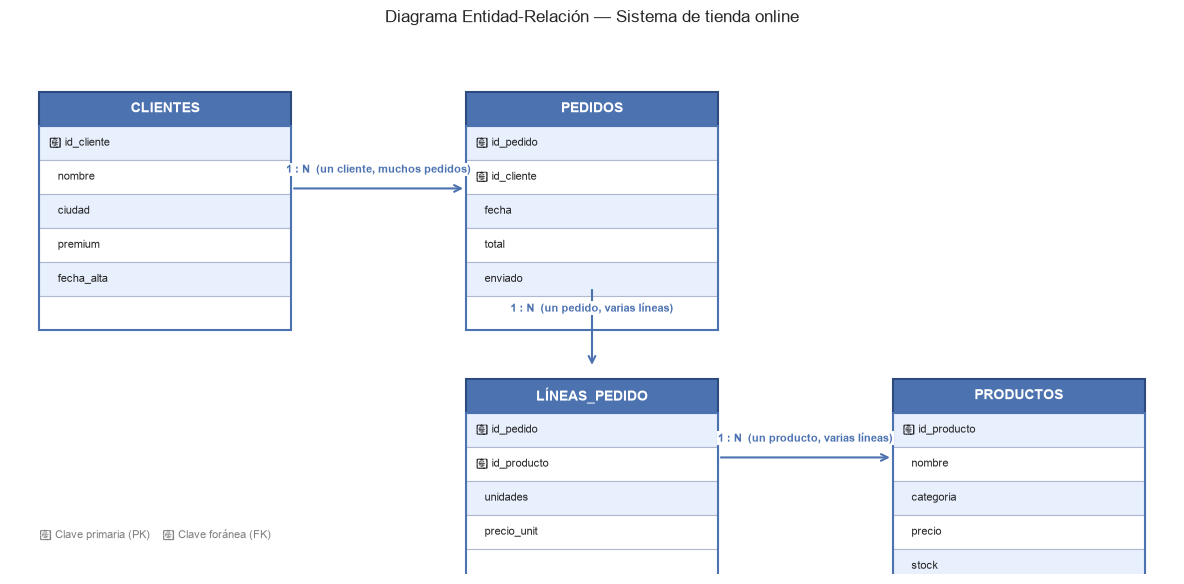

In [26]:
# Dibujamos un diagrama de entidad-relación simplificado con matplotlib
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

# ─── Estilo de caja ───
def draw_entity(ax, x, y, title, attrs, pk=None, fks=None):
    fks = fks or []
    row_h = 0.38
    total_h = row_h * (len(attrs) + 1)
    w = 2.6
    # Cabecera
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, row_h,
        boxstyle='square,pad=0', facecolor='#4C72B0', edgecolor='#2c4a80', linewidth=1.5))
    ax.text(x + w/2, y + row_h/2, title,
            ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    # Atributos
    for i, attr in enumerate(attrs):
        yy = y - (i + 1) * row_h
        color = '#e8f0fe' if i % 2 == 0 else 'white'
        ax.add_patch(mpatches.FancyBboxPatch((x, yy), w, row_h,
            boxstyle='square,pad=0', facecolor=color, edgecolor='#b0b8d0', linewidth=0.8))
        prefix = '🔑 ' if attr == pk else ('🔗 ' if attr in fks else '   ')
        ax.text(x + 0.1, yy + row_h/2, prefix + attr,
                ha='left', va='center', fontsize=8)
    ax.add_patch(mpatches.FancyBboxPatch((x, y - total_h), w, total_h,
        boxstyle='square,pad=0', facecolor='none', edgecolor='#4C72B0', linewidth=1.5))

def draw_arrow(ax, x1, y1, x2, y2, label, color='#4C72B0'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my + 0.15, label, ha='center', va='bottom', fontsize=8,
            color=color, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Entidades
draw_entity(ax, 0.3, 5.0, 'CLIENTES',
    ['id_cliente', 'nombre', 'ciudad', 'premium', 'fecha_alta'],
    pk='id_cliente')

draw_entity(ax, 4.7, 5.0, 'PEDIDOS',
    ['id_pedido', 'id_cliente', 'fecha', 'total', 'enviado'],
    pk='id_pedido', fks=['id_cliente'])

draw_entity(ax, 4.7, 1.8, 'LÍNEAS_PEDIDO',
    ['id_pedido', 'id_producto', 'unidades', 'precio_unit'],
    fks=['id_pedido', 'id_producto'])

draw_entity(ax, 9.1, 1.8, 'PRODUCTOS',
    ['id_producto', 'nombre', 'categoria', 'precio', 'stock'],
    pk='id_producto')

# Relaciones
draw_arrow(ax, 2.9, 4.3, 4.7, 4.3,   '1 : N  (un cliente, muchos pedidos)')
draw_arrow(ax, 6.0, 3.2, 6.0, 2.3,   '1 : N  (un pedido, varias líneas)')
draw_arrow(ax, 7.3, 1.3, 9.1, 1.3,   '1 : N  (un producto, varias líneas)')

# Leyenda
ax.text(0.3, 0.4, '🔑 Clave primaria (PK)    🔗 Clave foránea (FK)', fontsize=8, color='gray')

ax.set_title('Diagrama Entidad-Relación — Sistema de tienda online',
             fontsize=12, pad=10)
plt.tight_layout()
plt.show()

### 📌 Ejemplo 4 — Verificación de integridad referencial

In [27]:
# La integridad referencial garantiza que cada FK apunta a una PK que existe
# En datasets reales, esto puede no cumplirse (datos huérfanos, datos sucios)

def verificar_integridad(df_hijo, col_fk, df_padre, col_pk, nombre_relacion):
    """Detecta filas huérfanas: FKs que no tienen PK correspondiente."""
    valores_pk  = set(df_padre[col_pk].dropna())
    valores_fk  = df_hijo[col_fk].dropna()
    huerfanos   = valores_fk[~valores_fk.isin(valores_pk)]
    print(f'Relación {nombre_relacion}:')
    if huerfanos.empty:
        print(f'  ✅ Integridad referencial OK ({len(valores_fk)} referencias válidas)')
    else:
        print(f'  ❌ {len(huerfanos)} referencia/s huérfana/s: {huerfanos.tolist()}')

# Verificamos las relaciones del sistema
verificar_integridad(pedidos,       'id_cliente',  clientes,  'id_cliente',  'PEDIDOS → CLIENTES')
verificar_integridad(lineas_pedido, 'id_pedido',   pedidos,   'id_pedido',   'LÍNEAS  → PEDIDOS')
verificar_integridad(lineas_pedido, 'id_producto', productos, 'id_producto', 'LÍNEAS  → PRODUCTOS')

# Ahora introducimos un registro huérfano a propósito
pedidos_con_error = pd.concat([
    pedidos,
    pd.DataFrame([{'id_pedido': 9999, 'id_cliente': 99, 'fecha': '2026-03-01',
                   'total': 50.0, 'enviado': False}])
], ignore_index=True)

print()
verificar_integridad(pedidos_con_error, 'id_cliente', clientes, 'id_cliente', 'PEDIDOS_ERROR → CLIENTES')

Relación PEDIDOS → CLIENTES:
  ✅ Integridad referencial OK (6 referencias válidas)
Relación LÍNEAS  → PEDIDOS:
  ✅ Integridad referencial OK (8 referencias válidas)
Relación LÍNEAS  → PRODUCTOS:
  ✅ Integridad referencial OK (8 referencias válidas)

Relación PEDIDOS_ERROR → CLIENTES:
  ❌ 1 referencia/s huérfana/s: [99]


### 📌 Ejemplo 5 — Exploración de relaciones con `merge`

In [28]:
# El merge (equivalente al JOIN de SQL) permite combinar tablas usando las claves

# Relación 1:N — Pedidos con datos del cliente
pedidos_clientes = pedidos.merge(clientes, on='id_cliente', how='left')
print('Pedidos con datos del cliente (1:N):')
print(pedidos_clientes[['id_pedido', 'nombre', 'ciudad', 'fecha', 'total']].to_string(index=False))

Pedidos con datos del cliente (1:N):
 id_pedido        nombre   ciudad      fecha  total
      1001    Ana García  Sevilla 2026-01-10 269.97
      1002    Ana García  Sevilla 2026-01-12 349.00
      1003 Luis Martínez   Madrid 2026-01-15  45.50
      1004   María López   Málaga 2026-01-18  89.99
      1005   María López   Málaga 2026-02-01 379.49
      1006   Elena Pérez Valencia 2026-02-05  29.99


In [29]:
# Relación N:M — Qué productos contiene cada pedido
detalle = (
    lineas_pedido
    .merge(pedidos[['id_pedido', 'id_cliente', 'fecha']], on='id_pedido')
    .merge(clientes[['id_cliente', 'nombre', 'ciudad']], on='id_cliente')
    .merge(productos[['id_producto', 'nombre', 'categoria']], on='id_producto')
    .rename(columns={'nombre_x': 'cliente', 'nombre_y': 'producto'})
)

print('Vista completa de líneas de pedido (N:M resuelta):')
print(detalle[['id_pedido', 'cliente', 'fecha', 'producto', 'categoria',
               'unidades', 'precio_unit']].to_string(index=False))

Vista completa de líneas de pedido (N:M resuelta):
 id_pedido       cliente      fecha          producto   categoria  unidades  precio_unit
      1001    Ana García 2026-01-10  Teclado mecánico Periféricos         2        89.99
      1001    Ana García 2026-01-10 Ratón inalámbrico Periféricos         1        45.50
      1002    Ana García 2026-01-12       Monitor 27"   Pantallas         1       349.00
      1003 Luis Martínez 2026-01-15 Ratón inalámbrico Periféricos         1        45.50
      1004   María López 2026-01-18  Teclado mecánico Periféricos         1        89.99
      1005   María López 2026-02-01       Monitor 27"   Pantallas         1       349.00
      1005   María López 2026-02-01 Ratón inalámbrico Periféricos         1        45.50
      1006   Elena Pérez 2026-02-05         Hub USB-C  Accesorios         1        29.99


In [30]:
# Tipos de join y cuándo usarlos
print('Tipos de merge (equivalentes a SQL JOIN):')
print()
print('  INNER JOIN (how="inner"): solo filas con coincidencia en ambas tablas')
inner = pedidos.merge(clientes, on='id_cliente', how='inner')
print(f'  Resultado: {len(inner)} filas (de {len(pedidos)} pedidos y {len(clientes)} clientes)\n')

print('  LEFT JOIN (how="left"): todas las filas de la tabla izquierda + coincidencias de la derecha')
left = pedidos_con_error.merge(clientes, on='id_cliente', how='left')
print(f'  Resultado: {len(left)} filas — el pedido del cliente 99 queda con NaN en los campos del cliente')
print(left[left['nombre'].isna()][['id_pedido', 'id_cliente', 'nombre']].to_string(index=False))

print('\n  RIGHT JOIN (how="right"): todas las filas de la tabla derecha')
print('  OUTER JOIN (how="outer"): todas las filas de ambas tablas (NaN donde no hay coincidencia)')

Tipos de merge (equivalentes a SQL JOIN):

  INNER JOIN (how="inner"): solo filas con coincidencia en ambas tablas
  Resultado: 6 filas (de 6 pedidos y 5 clientes)

  LEFT JOIN (how="left"): todas las filas de la tabla izquierda + coincidencias de la derecha
  Resultado: 7 filas — el pedido del cliente 99 queda con NaN en los campos del cliente
 id_pedido  id_cliente nombre
      9999          99    NaN

  RIGHT JOIN (how="right"): todas las filas de la tabla derecha
  OUTER JOIN (how="outer"): todas las filas de ambas tablas (NaN donde no hay coincidencia)


### 📌 Ejemplo 6 — Granularidad: la unidad de análisis del dataset

In [31]:
# La GRANULARIDAD define qué representa cada fila del dataset
# Es fundamental identificarla antes de cualquier análisis

print('Granularidad de cada tabla del sistema:')
print()
tablas = {
    'clientes':      ('1 fila = 1 cliente',    clientes,      'id_cliente'),
    'productos':     ('1 fila = 1 producto',   productos,     'id_producto'),
    'pedidos':       ('1 fila = 1 pedido',     pedidos,       'id_pedido'),
    'lineas_pedido': ('1 fila = 1 línea',      lineas_pedido, None),
}

for nombre, (descripcion, df, pk) in tablas.items():
    n_filas = len(df)
    if pk:
        n_pk_unicos = df[pk].nunique()
        unicidad = '✅ PK única' if n_pk_unicos == n_filas else f'⚠️  {n_filas - n_pk_unicos} duplicados en PK'
    else:
        unicidad = '(PK compuesta: id_pedido + id_producto)'
    print(f'  {nombre:15s}: {n_filas:3d} filas | {descripcion:30s} | {unicidad}')

print()
print('💡 Si el modelo va a predecir si un PEDIDO se enviará puntualmente,')
print('   la unidad de análisis es el pedido → usaremos la tabla "pedidos" como base.')
print('   Las características de cliente y producto se añadirán mediante merge.')

Granularidad de cada tabla del sistema:

  clientes       :   5 filas | 1 fila = 1 cliente             | ✅ PK única
  productos      :   4 filas | 1 fila = 1 producto            | ✅ PK única
  pedidos        :   6 filas | 1 fila = 1 pedido              | ✅ PK única
  lineas_pedido  :   8 filas | 1 fila = 1 línea               | (PK compuesta: id_pedido + id_producto)

💡 Si el modelo va a predecir si un PEDIDO se enviará puntualmente,
   la unidad de análisis es el pedido → usaremos la tabla "pedidos" como base.
   Las características de cliente y producto se añadirán mediante merge.


### 📌 Ejemplo 7 — Volumetrías y descripción del esquema

In [32]:
def describir_esquema(tablas_dict):
    """
    Genera un resumen de volumetrías de un esquema multientidad.
    tablas_dict: dict {nombre: DataFrame}
    """
    print('═' * 70)
    print('  DESCRIPCIÓN DEL ESQUEMA DE DATOS')
    print('═' * 70)
    n_total_celdas = sum(df.shape[0] * df.shape[1] for df in tablas_dict.values())
    print(f'  Tablas:              {len(tablas_dict)}')
    print(f'  Total de registros:  {sum(len(df) for df in tablas_dict.values()):,}')
    print(f'  Total de celdas:     {n_total_celdas:,}')
    print()

    for nombre, df in tablas_dict.items():
        memoria = df.memory_usage(deep=True).sum()
        ausentes = df.isnull().sum().sum()
        print(f'  ── {nombre.upper()} '+ '─'*(45-len(nombre)))
        print(f'     Filas × columnas : {df.shape[0]:,} × {df.shape[1]}')
        print(f'     Memoria           : {memoria / 1024:.1f} KB')
        print(f'     Valores ausentes  : {ausentes}')
        print(f'     Columnas:          {df.columns.tolist()}')
        print()
    print('═' * 70)

describir_esquema({
    'clientes':      clientes,
    'productos':     productos,
    'pedidos':       pedidos,
    'lineas_pedido': lineas_pedido
})

══════════════════════════════════════════════════════════════════════
  DESCRIPCIÓN DEL ESQUEMA DE DATOS
══════════════════════════════════════════════════════════════════════
  Tablas:              4
  Total de registros:  23
  Total de celdas:     107

  ── CLIENTES ─────────────────────────────────────
     Filas × columnas : 5 × 5
     Memoria           : 0.9 KB
     Valores ausentes  : 0
     Columnas:          ['id_cliente', 'nombre', 'ciudad', 'premium', 'fecha_alta']

  ── PRODUCTOS ────────────────────────────────────
     Filas × columnas : 4 × 5
     Memoria           : 0.8 KB
     Valores ausentes  : 0
     Columnas:          ['id_producto', 'nombre', 'categoria', 'precio', 'stock']

  ── PEDIDOS ──────────────────────────────────────
     Filas × columnas : 6 × 5
     Memoria           : 0.3 KB
     Valores ausentes  : 0
     Columnas:          ['id_pedido', 'id_cliente', 'fecha', 'total', 'enviado']

  ── LINEAS_PEDIDO ────────────────────────────────
     Filas × column

### 📌 Ejemplo 8 — Identificar entidades en un dataset desnormalizado

In [ ]:
# En la práctica, a menudo recibimos datasets desnormalizados (todo en una tabla)
# Hay que identificar qué entidades están «colapsadas» en él

# Vista desnormalizada del sistema de tienda
# 'detalle' ya incluye 'ciudad' (viene del merge con clientes), así que no
# hace falta volver a mergearla: solo seleccionamos las columnas que interesan
vista_plana = (
    detalle
    [['id_pedido', 'cliente', 'ciudad', 'fecha', 'producto', 'categoria', 'unidades', 'precio_unit']]
    .copy()
)
vista_plana['importe_linea'] = vista_plana['unidades'] * vista_plana['precio_unit']

print('Dataset desnormalizado (todo en una tabla):')
print(vista_plana.to_string(index=False))

print('\n¿Cuántas entidades distintas hay en este dataset plano?')
print(f'  Clientes únicos : {vista_plana["cliente"].nunique()}')
print(f'  Pedidos únicos  : {vista_plana["id_pedido"].nunique()}')
print(f'  Productos únicos: {vista_plana["producto"].nunique()}')
print(f'  Total filas     : {len(vista_plana)}')
print()
print('💡 La granularidad aquí es la LÍNEA DE PEDIDO, no el pedido ni el cliente.')
print('   Si quisiéramos analizar a nivel de pedido, habría que agregar primero:')
print('   vista_plana.groupby("id_pedido")["importe_linea"].sum()')

In [13]:
# Detección de redundancia: atributos que se repiten por pertenencer a otra entidad
# Si 'ciudad' depende de 'cliente' (no de 'id_pedido'), aparecerá repetida

print('Redundancia detectada: ¿"ciudad" es constante para cada cliente?')
redundancia = (
    vista_plana.groupby('cliente')['ciudad']
    .nunique()
    .rename('ciudades_distintas')
)
print(redundancia)
print()
if (redundancia == 1).all():
    print('✅ Sí: cada cliente tiene siempre la misma ciudad.')
    print('   → "ciudad" es un atributo de CLIENTES, no de LÍNEAS_PEDIDO.')
    print('   → En un modelo, habría que extraerla a su propia tabla para evitar redundancia.')

Redundancia detectada: ¿"ciudad" es constante para cada cliente?
cliente
Ana García       1
Elena Pérez      1
Luis Martínez    1
María López      1
Name: ciudades_distintas, dtype: int64

✅ Sí: cada cliente tiene siempre la misma ciudad.
   → "ciudad" es un atributo de CLIENTES, no de LÍNEAS_PEDIDO.
   → En un modelo, habría que extraerla a su propia tabla para evitar redundancia.


---
### 🔧 Ejercicio 1 — Identificación de entidades en el dataset Titanic

El Titanic es un dataset desnormalizado. Analiza qué entidades están representadas y cómo se relacionan.

In [14]:
titanic = sns.load_dataset('titanic')

# TAREA 1: ¿Cuál es la granularidad del dataset? (¿qué representa cada fila?)
# Respuesta: ...

# TAREA 2: Además de «Pasajero», ¿qué otras entidades puedes identificar?
#   Pista: piensa en la cabina (deck), el barco, la clase del billete...
# Respuesta: ...

# TAREA 3: ¿Hay algún atributo que podría ser la clave primaria del pasajero?
#   Comprueba si 'name' o 'ticket' son únicos
# print(titanic['name'].nunique() == len(titanic)   if 'name' in titanic.columns else 'col no existe')
# print(titanic['ticket'].nunique())

# TAREA 4: La columna 'deck' (cubierta) tiene muchos NaN.
#   ¿Podría extraerse como entidad separada? ¿Cuál sería su relación con Pasajero?
# Respuesta: ...

# TAREA 5: Si quisiéramos normalizar el dataset en tablas separadas,
#   ¿cuántas tablas necesitaríamos? Define cada una con su PK y atributos.
# Respuesta: ...

print('Completa las tareas y reflexiones comentadas arriba.')

Completa las tareas y reflexiones comentadas arriba.


---
### 🔧 Ejercicio 2 — Esquema multientidad: sistema hospitalario

Diseña y crea en Python un esquema de datos para un sistema hospitalario simplificado.

In [15]:
# TAREA 1: Crea los siguientes DataFrames con datos de ejemplo (mínimo 4 filas cada uno):
#   - pacientes:  id_paciente (PK), nombre, fecha_nacimiento, genero, ciudad
#   - medicos:    id_medico (PK), nombre, especialidad, turno
#   - consultas:  id_consulta (PK), id_paciente (FK), id_medico (FK), fecha, diagnostico, coste

# pacientes = pd.DataFrame({...})
# medicos   = pd.DataFrame({...})
# consultas = pd.DataFrame({...})

# TAREA 2: Verifica la integridad referencial de las dos FKs en 'consultas'
#   usando la función verificar_integridad definida en el Ejemplo 4
# verificar_integridad(consultas, 'id_paciente', pacientes, 'id_paciente', 'CONSULTAS → PACIENTES')
# verificar_integridad(consultas, 'id_medico',   medicos,   'id_medico',   'CONSULTAS → MEDICOS')

# TAREA 3: Usa merge para obtener una vista plana con: nombre del paciente,
#   nombre y especialidad del médico, fecha y diagnóstico de cada consulta
# ...

# TAREA 4: ¿Cuál es la cardinalidad de la relación médico-paciente?
#   ¿Puede un paciente ser atendido por varios médicos? ¿Y un médico atender a varios pacientes?
# Respuesta: ...

# TAREA 5: Aplica describir_esquema() al diccionario de tus tres tablas
# describir_esquema({'pacientes': pacientes, 'medicos': medicos, 'consultas': consultas})

print('Completa las tareas comentadas arriba.')

Completa las tareas comentadas arriba.


---
### 🔧 Ejercicio 3 — Del dataset desnormalizado al esquema normalizado

Se te proporciona un dataset plano de un sistema de recursos humanos. Identifica las entidades, sus atributos y las relaciones, y sepáralo en tablas normalizadas.

In [16]:
# Dataset desnormalizado de RRHH
rrhh_plano = pd.DataFrame({
    'id_empleado':        [1, 2, 3, 4, 5, 6],
    'nombre_empleado':    ['Ana García', 'Luis Martínez', 'María López',
                           'Carlos Ruiz', 'Elena Pérez', 'Pedro Sanz'],
    'fecha_nacimiento':   ['1995-03-12', '1988-07-25', '1992-11-03',
                           '1979-01-15', '1990-06-20', '1985-09-08'],
    'id_departamento':    [10, 20, 10, 30, 20, 30],
    'nombre_departamento':['Tecnología', 'Ventas', 'Tecnología',
                           'Dirección', 'Ventas', 'Dirección'],
    'ubicacion_depto':    ['Madrid', 'Sevilla', 'Madrid', 'Madrid', 'Sevilla', 'Madrid'],
    'id_proyecto':        [101, 102, 101, 103, 102, 103],
    'nombre_proyecto':    ['Alpha', 'Beta', 'Alpha', 'Gamma', 'Beta', 'Gamma'],
    'horas_proyecto':     [120, 80, 95, 200, 110, 150],
    'salario':            [35000, 28000, 32000, 55000, 31000, 48000]
})

print('Dataset plano de RRHH:')
print(rrhh_plano.to_string(index=False))

Dataset plano de RRHH:
 id_empleado nombre_empleado fecha_nacimiento  id_departamento nombre_departamento ubicacion_depto  id_proyecto nombre_proyecto  horas_proyecto  salario
           1      Ana García       1995-03-12               10          Tecnología          Madrid          101           Alpha             120    35000
           2   Luis Martínez       1988-07-25               20              Ventas         Sevilla          102            Beta              80    28000
           3     María López       1992-11-03               10          Tecnología          Madrid          101           Alpha              95    32000
           4     Carlos Ruiz       1979-01-15               30           Dirección          Madrid          103           Gamma             200    55000
           5     Elena Pérez       1990-06-20               20              Ventas         Sevilla          102            Beta             110    31000
           6      Pedro Sanz       1985-09-08              

In [17]:
# TAREA 1: Identifica las entidades presentes en el dataset plano
#           y los atributos que pertenecen a cada una
# Entidades: Empleado, Departamento, Proyecto

# TAREA 2: ¿Qué tipo de relación existe entre Empleado y Proyecto?
#           ¿Y entre Empleado y Departamento?
# Respuesta: ...

# TAREA 3: Extrae cada entidad en su propio DataFrame (normalización)
#   departamentos = rrhh_plano[['id_departamento', 'nombre_departamento', 'ubicacion_depto']].drop_duplicates()
#   proyectos     = ...
#   empleados     = ...
#   asignaciones  = ...  # tabla intermedia empleado-proyecto

# TAREA 4: Verifica la integridad referencial de todas las FKs

# TAREA 5: Usa describir_esquema() para documentar el esquema normalizado

print('Completa las tareas de normalización.')

Completa las tareas de normalización.


---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| Entidad | Objeto del mundo real sobre el que se registra información. Cada fila de una tabla representa una instancia de una entidad. |
| Atributo | Propiedad de una entidad. Corresponde a una columna del DataFrame. |
| Clave primaria (PK) | Identifica unívocamente cada instancia. Comprobar con `nunique() == len(df)`. |
| Clave foránea (FK) | Referencia a la PK de otra entidad. Verificar integridad con `isin()`. |
| Cardinalidad | 1:1 (biyección), 1:N (padre-hijo), N:M (tabla intermedia). |
| Granularidad | Qué representa cada fila. Definirla correctamente evita agregaciones erróneas. |
| `merge()` | Equivalente al JOIN de SQL. `how` controla el tipo: inner, left, right, outer. |
| Dataset desnormalizado | Múltiples entidades colapsadas en una sola tabla. Identificar redundancias con `groupby + nunique`. |

### 🔜 Próxima sesión
**Bloque 1 — Sesión 3:** Formatos de almacenamiento habituales (CSV, JSON, XML, Excel, SQL), carga de datos con pandas y repositorios públicos de datos para ML.